# A5 CW Solutions: Fitting QNMs
### Joey Wee

- Let's start by examining and plotting the data.dat file.

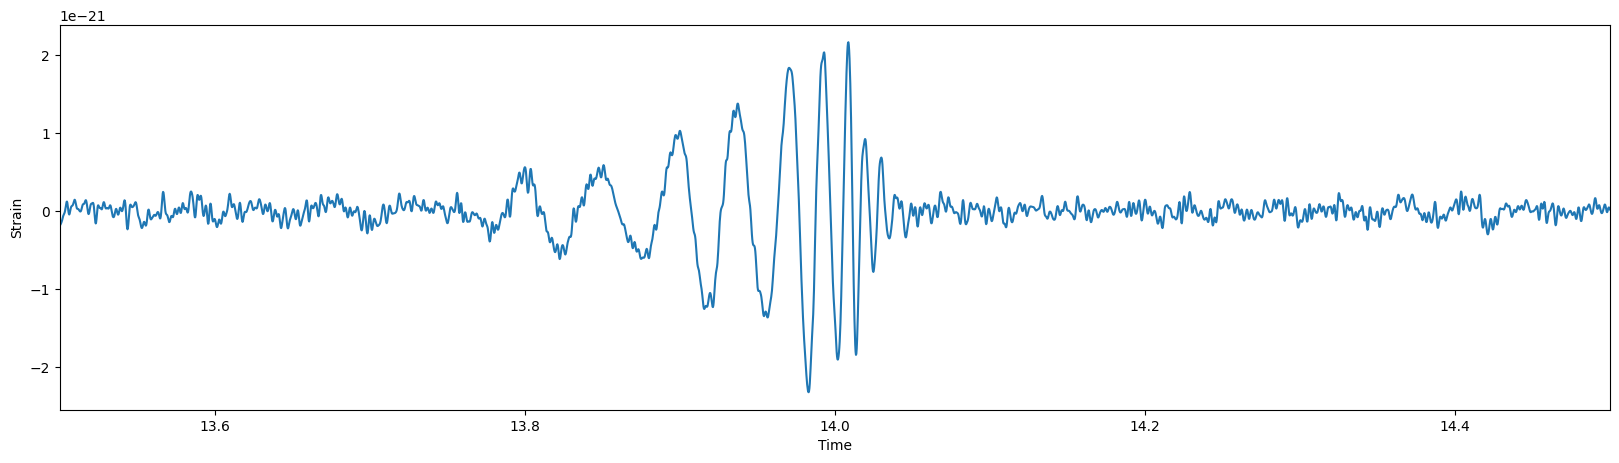

In [30]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat', skiprows=1)

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(data[:,0], data[:,1])
ax.set_xlim(13.5,14.5)

t = data[:,0]
strain = data[:,1]


In [22]:
import qnm
qnm.download_data()

Destination path C:\Users\Joey\.qnm\data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


- Any black hole can be described by the mass $M$ and the angular momentum $J = \chi M^2$. $\chi \in [0,1[$ 

## Q1: Calculate the dimensionless frequencies
- Consider (l, m, n) = (2, 2, 0) and (3, 3, 0)
- Calculate the dimensionless frequencies.
- Plot the real and imaginary parts of those frequencies.
    - The real part is the oscillatin' part.
    - The imaginary part causes the pertrubation to decay in time.


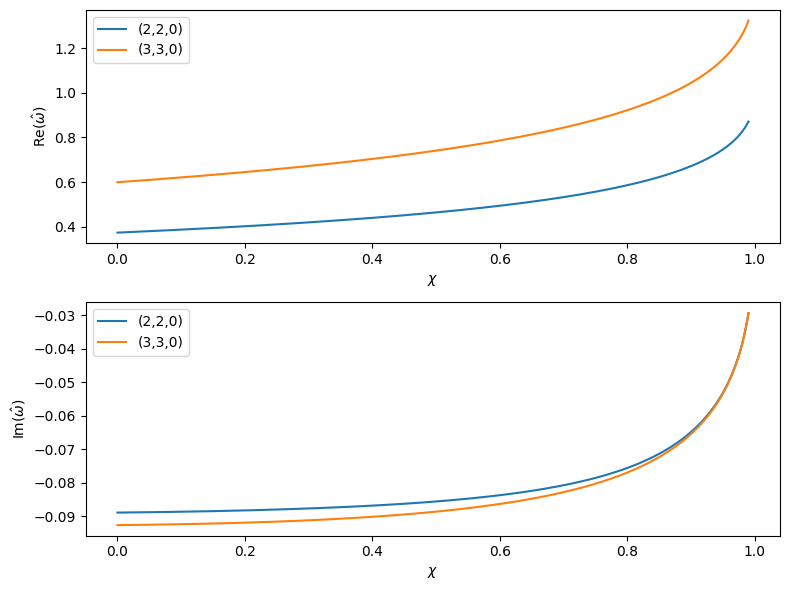

In [23]:
chi_values = np.linspace(0, 0.99, 1000)

# Storage
omega_220 = []
omega_330 = []

# Get mode objects
mode_220 = qnm.modes_cache(s=-2, l=2, m=2, n=0)
mode_330 = qnm.modes_cache(s=-2, l=3, m=3, n=0)

# Loop over chi values
for chi in chi_values:
    w220, _, _ = mode_220(chi)
    w330, _, _ = mode_330(chi)
    omega_220.append(w220)
    omega_330.append(w330)

# Convert to numpy arrays
omega_220 = np.array(omega_220)
omega_330 = np.array(omega_330)

# Now plot real and imaginary parts separately
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(chi_values, omega_220.real, label='(2,2,0)')
ax1.plot(chi_values, omega_330.real, label='(3,3,0)')
ax1.set_ylabel(r'$\mathrm{Re}(\hat{\omega})$')

ax2.plot(chi_values, omega_220.imag, label='(2,2,0)')
ax2.plot(chi_values, omega_330.imag, label='(3,3,0)')
ax2.set_ylabel(r'$\mathrm{Im}(\hat{\omega})$')

for ax in (ax1, ax2):
    ax.set_xlabel(r'$\chi$')
    ax.legend()

plt.tight_layout()
plt.show()

## Q2: Splitting Data
- Data has off and on-source regimes. How should I split them?
- There is also a time $t_0$ where the ringdown begins. How to identify?
- *Only analyse on-source at $t>t_0$*.

----
- Ideas:
    - Find peaks to find the maxima and minima. The highest can be the start of ringodown. 
    - Moving window. When is variance larger? This can find on-source.
    - Spectrogram to find on source? Can identify region where the signals are clearly different.

#### Spectrogram

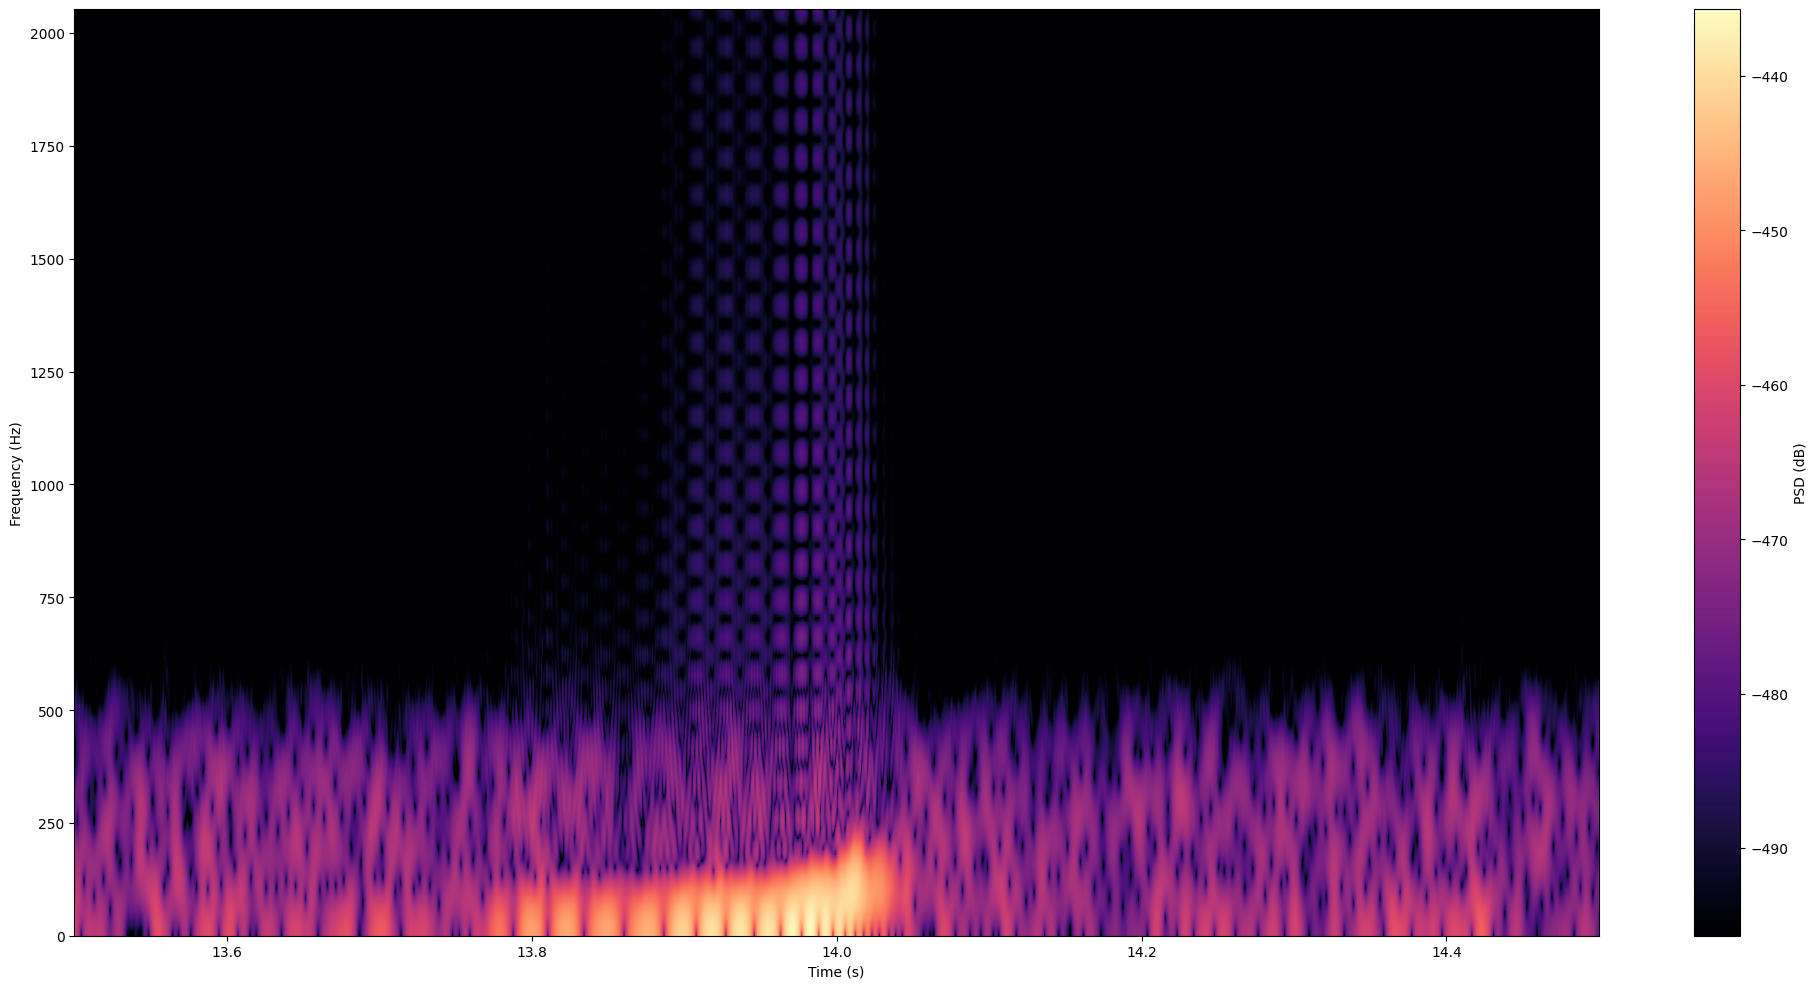

In [32]:
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian


# 32 seconds of data at 4096 Hz
# Let's spectrogram at 100 Hz
 
T_x = 1/4096 # Time between samples
N = len(t) # Number of samples

# Time indices for the signal
t_x = np.arange(N) * T_x # N time ppoints spanning across N*T_x seconds

# Create windows using Gaussian weighting to prevent frequency artefacts
g_std = 12 # Width of Gaussian window
win  = gaussian(50, std=g_std, sym=True)
SFT = ShortTimeFFT(win, hop=2, fs=1/T_x, mfft=800, scale_to='psd')
Sx2 = SFT.spectrogram(strain) # Magnitude squared "x2"

Sx_dB = 10 * np.log10(np.fmax(Sx2, Sx2.max() * 1e-6))

fig, ax = plt.subplots(figsize= (20,10))
t_lo, t_hi = SFT.extent(N)[:2] # Slightly wider time range because of the windows
ax.set_xlim(13.5,14.5)
im = ax.imshow(Sx_dB, origin='lower', aspect='auto',
               extent=SFT.extent(N), cmap='magma')
ax.set(xlabel='Time (s)', ylabel='Frequency (Hz)')
fig.colorbar(im, label='PSD (dB)')
fig.tight_layout()
plt.show()





- We can see here that, compared to the background, 13.7 to 14.1 is different. We can treat this as out on-signal time. 
- This agrees with the strain vs time plot well.
- We can use a Hilbert transform the signal to get the amplitude term.
- We take the peak of this amplitude to be the start of our ringdown time $t_0$.

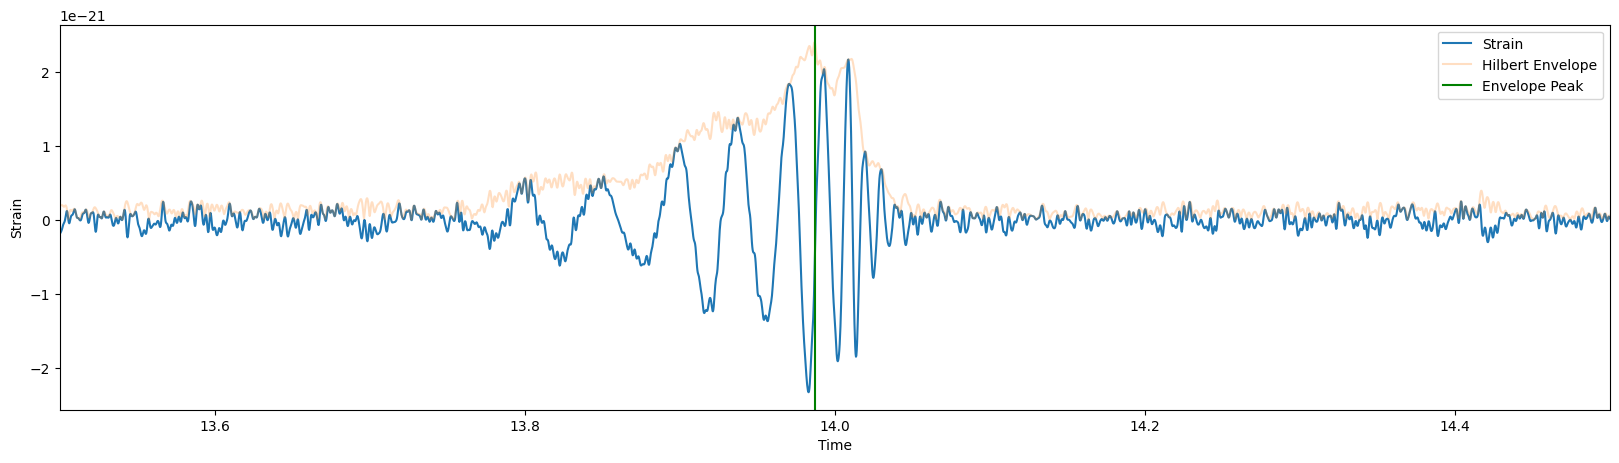

In [37]:
from scipy.signal import hilbert

analytic = hilbert(strain)
envelope = np.abs(analytic)
t0 = t[np.argmax(envelope)]

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(t, strain, label='Strain')
ax.plot(t, envelope, alpha=0.25, label='Hilbert Envelope')
ax.axvline(t0, color='green', label='Envelope Peak')
ax.set_xlim(13.5,14.5)
ax.legend()

(13.5, 14.5)

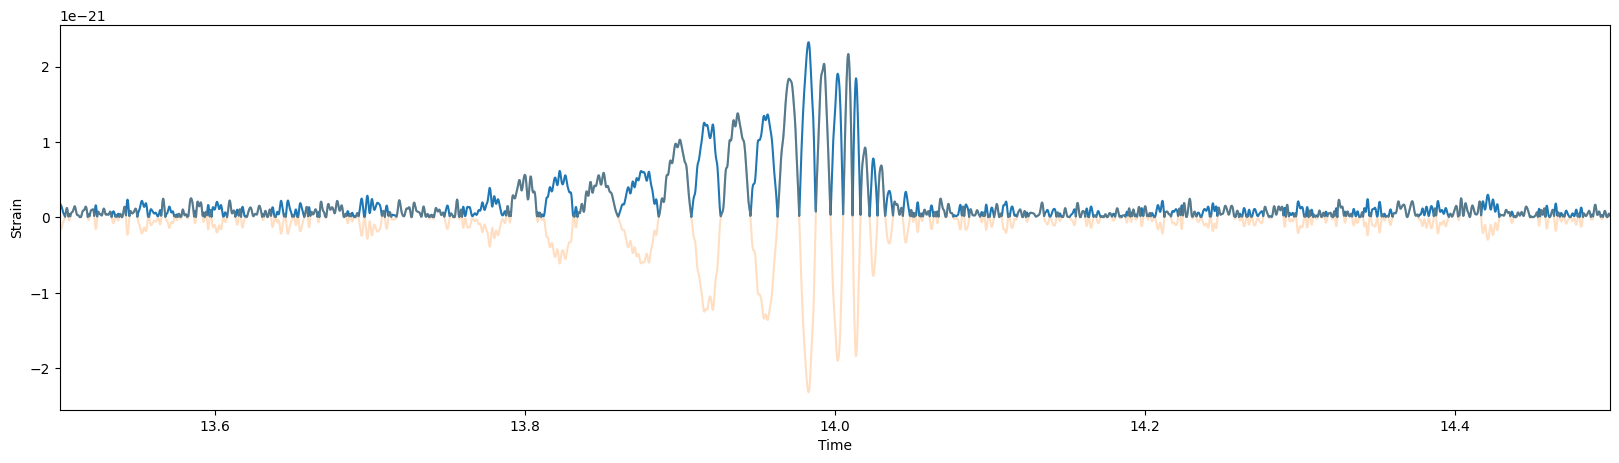

In [28]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(data[:,0], np.abs(data[:,1]))
ax.plot(data[:,0], data[:,1], alpha = 0.25)
ax.set_xlim(13.5,14.5)